In [12]:
# 0_environment.py
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, RepeatVector, TimeDistributed
from tensorflow.keras.callbacks import EarlyStopping
import joblib
np.random.seed(42); tf.random.set_seed(42)




In [13]:
df = pd.read_csv("player_features_final.csv")
print("rows:", len(df))
print(df.columns.tolist())
# Ensure numeric fields exist
for c in ['market_value_in_eur','highest_market_value_in_eur']:
    if c not in df.columns:
        raise SystemExit(f"Required column missing: {c}")



rows: 20589
['player_id', 'first_name', 'last_name', 'name', 'last_season', 'current_club_id', 'player_code', 'country_of_birth', 'city_of_birth', 'country_of_citizenship', 'date_of_birth', 'sub_position', 'position', 'foot', 'height_in_cm', 'contract_expiration_date', 'agent_name', 'image_url', 'url', 'current_club_domestic_competition_id', 'current_club_name', 'market_value_in_eur', 'highest_market_value_in_eur', 'position_encoded', 'club_encoded', 'experience', 'value_drop_ratio', 'sentiment_score']


In [14]:
# 2_helpers.py
def synthesize_player_series(df, seq_len=8, pred_steps=1, noise_scale=0.05, seed=42):
    np.random.seed(seed)
    rows = []
    players = df.to_dict('records')
    for p in players:
        pid = p['player_id']
        cur = float(p.get('market_value_in_eur', np.nan) or 0.0)
        high = float(p.get('highest_market_value_in_eur', np.nan) or cur)
        # if highest is zero or equal to current, create small growth/decline
        if high <= 0:
            high = cur * 1.1 if cur>0 else 1000000.0
        # build timeline from older (high) to current:
        total_steps = seq_len + pred_steps
        # linear interpolation from high -> cur
        vals = np.linspace(high, cur, total_steps)
        # add small multiplicative noise (proportional)
        noise = 1 + np.random.normal(loc=0.0, scale=noise_scale, size=total_steps)
        vals_noisy = vals * noise
        # sentiment base
        base_sent = float(p.get('sentiment_score', 0.0) or 0.0)
        sent = base_sent + np.random.normal(0, 0.02, size=total_steps)  # small variation
        # injury flag: if present keep else random small chance
        if 'injury_flag' in df.columns:
            inj_base = p.get('injury_flag', 0)
            inj = np.clip(np.round(np.random.binomial(1, 0.05, size=total_steps) * inj_base), 0, 1)
        else:
            inj = np.random.binomial(1, 0.03, size=total_steps)  # 3% chance at any timestep
        # position/club encodings (carry forward)
        pos = p.get('position_encoded', np.nan)
        club = p.get('club_encoded', np.nan)
        # date: create pseudo-dates if none present
        for t in range(total_steps):
            rows.append({
                'player_id': pid,
                'timestep': t,           # synthetic time index (0..)
                'market_value_in_eur': float(vals_noisy[t]),
                'sentiment_score': float(sent[t]),
                'injury_flag': int(inj[t]),
                'position_encoded': pos,
                'club_encoded': club
            })
    synth_df = pd.DataFrame(rows)
    return synth_df

# create synthetic dataset
SEQ_LEN = 8
PRED_STEPS = 1
synth_df = synthesize_player_series(df, seq_len=SEQ_LEN, pred_steps=PRED_STEPS, noise_scale=0.05)
print("Synthetic rows:", len(synth_df))
synth_df.to_csv("player_synth_timeseries.csv", index=False)



Synthetic rows: 185301


In [15]:
def build_sequences(df_ts, feature_cols, value_col='market_value_in_eur', seq_len=8, pred_steps=1, player_col='player_id', time_col='timestep'):
    X_list, y_list = [], []
    grouped = df_ts.groupby(player_col)
    for pid, g in grouped:
        g = g.sort_values(time_col)
        if len(g) < seq_len + pred_steps:
            continue
        arr = g[feature_cols].values
        vals = g[value_col].values
        for i in range(len(g) - seq_len - pred_steps + 1):
            X_list.append(arr[i:i+seq_len])
            y_list.append(vals[i+seq_len:i+seq_len+pred_steps])
    if not X_list:
        return None, None
    X = np.array(X_list)
    y = np.array(y_list)
    return X, y

# Univariate sequences
feature_uni = ['market_value_in_eur']
X_uni, y_uni = build_sequences(synth_df, feature_uni, seq_len=SEQ_LEN, pred_steps=PRED_STEPS)
y_uni = y_uni.reshape(y_uni.shape[0],)  # flatten
print("Univariate samples:", X_uni.shape if X_uni is not None else None)

# Multivariate sequences (add sentiment, injury)
feature_mv = ['market_value_in_eur','sentiment_score','injury_flag']
X_mv, y_mv = build_sequences(synth_df, feature_mv, seq_len=SEQ_LEN, pred_steps=PRED_STEPS)
y_mv = y_mv.reshape(y_mv.shape[0],)
print("Multivariate samples:", X_mv.shape if X_mv is not None else None)


Univariate samples: (20589, 8, 1)
Multivariate samples: (20589, 8, 3)


In [16]:
def fit_scaler_and_scale(X_train, y_train=None):
    ns, sl, nf = X_train.shape
    flatX = X_train.reshape(-1, nf)
    X_scaler = MinMaxScaler().fit(flatX)
    Xs = X_scaler.transform(flatX).reshape(ns, sl, nf)
    y_scaler = None
    if y_train is not None:
        y_scaler = MinMaxScaler().fit(y_train.reshape(-1,1))
    return Xs, X_scaler, y_scaler

# Split & scale for univariate
Xtr, Xte, ytr, yte = train_test_split(X_uni, y_uni, test_size=0.2, random_state=42, shuffle=True)
Xtr_s, X_scaler, y_scaler = fit_scaler_and_scale(Xtr, ytr)
Xte_s = X_scaler.transform(Xte.reshape(-1, Xte.shape[2])).reshape(Xte.shape[0], Xte.shape[1], Xte.shape[2])
ytr_s = y_scaler.transform(ytr.reshape(-1,1)).flatten()
yte_s = y_scaler.transform(yte.reshape(-1,1)).flatten()


c:\Users\saura\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - loss: 0.0257 - val_loss: 0.0230
Epoch 2/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0233 - val_loss: 0.0217
Epoch 3/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0217 - val_loss: 0.0203
Epoch 4/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0215 - val_loss: 0.0206
Epoch 5/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0214 - val_loss: 0.0206
Epoch 6/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0212 - val_loss: 0.0206
Epoch 7/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0213 - val_loss: 0.0207
Epoch 8/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0214 - val_loss: 0.0206
Epoch 9/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0213 - val_loss: 0.0207
Epoch 10/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0212 - val_loss: 0.0206
Epoch 11/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0212 - val_loss: 0.0205
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


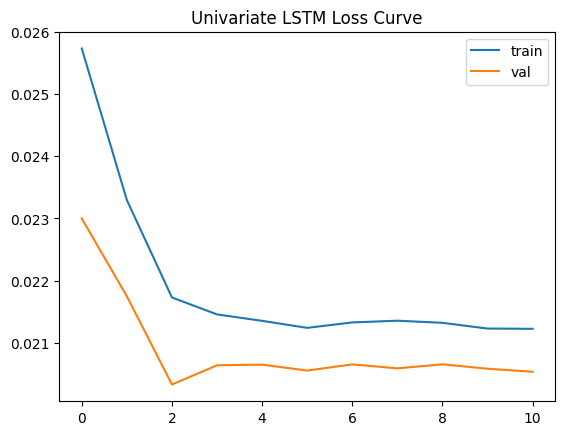

In [19]:
# model
from sklearn.metrics import mean_squared_error, mean_absolute_error

# model
def build_univariate_lstm(input_shape, units=64):
    m = Sequential([
        LSTM(units, input_shape=input_shape),
        Dropout(0.2),
        Dense(1)
    ])
    m.compile(optimizer='adam', loss='mse')
    return m

model_uni = build_univariate_lstm((Xtr_s.shape[1], Xtr_s.shape[2]), units=64)

es = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)

hist_uni = model_uni.fit(
    Xtr_s, ytr_s,
    validation_split=0.1,
    epochs=50,
    batch_size=128,
    callbacks=[es]
)

# 🔥 Predict + invert scaling
y_pred_s = model_uni.predict(Xte_s).flatten()
y_pred = y_scaler.inverse_transform(y_pred_s.reshape(-1,1)).flatten()

# 📌 Evaluate
mse = mean_squared_error(yte, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(yte, y_pred)


print("Univariate RMSE:", rmse)
print("Univariate MAE:", mae)

# 📊 Plot loss curve
plt.plot(hist_uni.history['loss'], label='train')
plt.plot(hist_uni.history['val_loss'], label='val')
plt.legend()
plt.title('Univariate LSTM Loss Curve')
plt.show()


Multivariate LSTM -- Metrics
RMSE: 0.85
MAE : 0.56


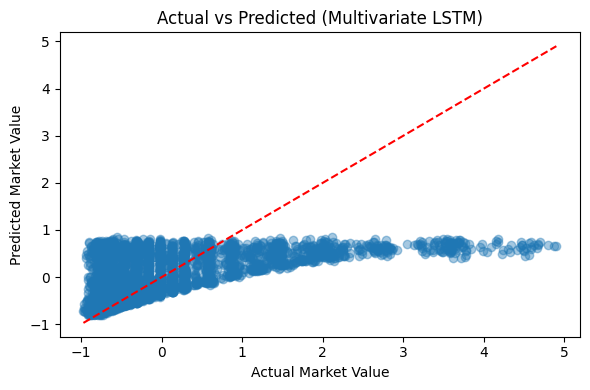

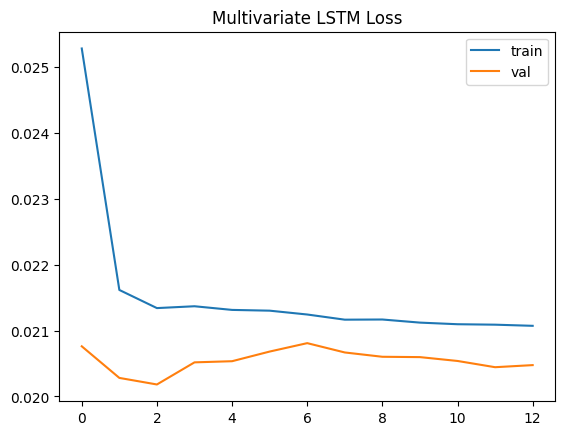

In [22]:
# prepare multivariate data
# --- imports required for evaluation (add at top of the cell if missing) ---
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import matplotlib.pyplot as plt

# --- after predicting and inverting to original units ---
# yte_mv  -> actuals (original units)
# y_pred_mv -> predicted values (original units)

# Compute MSE -> RMSE, and MAE
mse_mv = mean_squared_error(yte_mv, y_pred_mv)
rmse_mv = np.sqrt(mse_mv)
mae_mv = mean_absolute_error(yte_mv, y_pred_mv)

print("Multivariate LSTM -- Metrics")
print(f"RMSE: {rmse_mv:.2f}")
print(f"MAE : {mae_mv:.2f}")

# Optional: scatter plot of Actual vs Predicted
plt.figure(figsize=(6,4))
plt.scatter(yte_mv, y_pred_mv, alpha=0.4)
plt.plot([yte_mv.min(), yte_mv.max()], [yte_mv.min(), yte_mv.max()], 'r--')  # perfect prediction line
plt.xlabel("Actual Market Value")
plt.ylabel("Predicted Market Value")
plt.title("Actual vs Predicted (Multivariate LSTM)")
plt.tight_layout()
plt.show()

# Loss curve (if hist_mv exists)
if 'hist_mv' in globals():
    plt.figure()
    plt.plot(hist_mv.history.get('loss', []), label='train')
    plt.plot(hist_mv.history.get('val_loss', []), label='val')
    plt.legend(); plt.title('Multivariate LSTM Loss'); plt.show()



Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 8, 3)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        17,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_1 (RepeatVector)  │ (None, 2, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 2, 64)          │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 2, 32)          │         2,080 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (None, 2, 1)           │            33 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,545 (205.25 KB)

 Trainable params: 52,545 (205.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0176 - val_loss: 7.5399e-04
Epoch 2/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.7811e-04 - val_loss: 6.1036e-04
Epoch 3/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.7116e-04 - val_loss: 5.9753e-04
Epoch 4/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.6679e-04 - val_loss: 5.9608e-04
Epoch 5/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.6009e-04 - val_loss: 5.7777e-04
Epoch 6/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.5181e-04 - val_loss: 5.7004e-04
Epoch 7/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.4471e-04 - val_loss: 5.6508e-04
Epoch 8/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.3584e-04 - val_loss: 5.6044e-04
Epoch 9/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3171e-04 - val_loss: 5.5810e-04
Epoch 10/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.2832e-04 - val_loss: 5.5741e-04
Epoch 11/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.

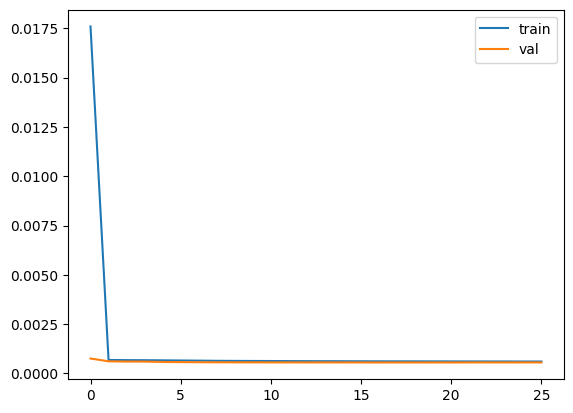

In [3]:
# FAST MODE: smaller model + fewer samples + fewer epochs
import numpy as np, pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.layers import LSTM, RepeatVector, TimeDistributed, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

np.random.seed(42); tf.random.set_seed(42)

# load synth_df (assumes you already created it)
# reduce samples by sampling players
player_sample_frac = 0.10   # use 10% of players for fast run (adjust up if you want)
unique_players = synth_df['player_id'].unique()
sampled_players = np.random.choice(unique_players, size=max(1,int(len(unique_players)*player_sample_frac)), replace=False)
synth_small = synth_df[synth_df['player_id'].isin(sampled_players)].copy()

# FAST hyperparams
SEQ_LEN = 8
OUT_STEPS = 2
LATENT_DIM = 64
BATCH_SIZE = 64
EPOCHS = 30

# build sequences (same helper as before)
def build_sequences(df_ts, feature_cols, seq_len, pred_steps):
    X_list, y_list = [], []
    for pid, g in df_ts.groupby('player_id'):
        g = g.sort_values('timestep')
        if len(g) < seq_len + pred_steps: continue
        arr = g[feature_cols].values
        vals = g['market_value_in_eur'].values
        for i in range(len(g) - seq_len - pred_steps + 1):
            X_list.append(arr[i:i+seq_len])
            y_list.append(vals[i+seq_len:i+seq_len+pred_steps])
    if not X_list: return None, None
    return np.array(X_list), np.array(y_list)

feature_cols = ['market_value_in_eur','sentiment_score','injury_flag']
X, y = build_sequences(synth_small, feature_cols, seq_len=SEQ_LEN, pred_steps=OUT_STEPS)
if X is None:
    raise SystemExit("No sequences found for small sample — try increasing player_sample_frac or lowering seq_len/out_steps.")

# reshape y
y3 = y.reshape(y.shape[0], y.shape[1], 1)

# split & scale
Xtr, Xte, ytr, yte = train_test_split(X, y3, test_size=0.2, random_state=42)
ns, sl, nf = Xtr.shape
X_scaler = MinMaxScaler().fit(Xtr.reshape(-1, nf))
Xtr_s = X_scaler.transform(Xtr.reshape(-1, nf)).reshape(ns, sl, nf)
Xte_s = X_scaler.transform(Xte.reshape(-1, nf)).reshape(Xte.shape[0], sl, nf)
y_scaler = MinMaxScaler().fit(ytr.reshape(-1,1))
ytr_s = y_scaler.transform(ytr.reshape(-1,1)).reshape(ytr.shape)
yte_s = y_scaler.transform(yte.reshape(-1,1)).reshape(yte.shape)

# model
from tensorflow.keras import Input
inp = Input(shape=(SEQ_LEN, nf))
enc = LSTM(LATENT_DIM)(inp)
rep = RepeatVector(OUT_STEPS)(enc)
dec = LSTM(LATENT_DIM, return_sequences=True)(rep)
dec = TimeDistributed(Dense(32, activation='relu'))(dec)
out = TimeDistributed(Dense(1))(dec)
model = Model(inp, out)
model.compile(optimizer='adam', loss='mse')
model.summary()

es = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
hist = model.fit(Xtr_s, ytr_s, validation_split=0.1, epochs=EPOCHS, batch_size=BATCH_SIZE, callbacks=[es], verbose=1)

# predict & eval (invert scaling)
y_pred_s = model.predict(Xte_s)
y_pred = y_scaler.inverse_transform(y_pred_s.reshape(-1,1)).reshape(y_pred_s.shape[0], OUT_STEPS)
y_true = yte.reshape(yte.shape[0], OUT_STEPS)

import numpy as np
rmse_per = np.sqrt(((y_true - y_pred)**2).mean(axis=0))
mae_per = np.mean(np.abs(y_true - y_pred), axis=0)
print("RMSE per horizon:", rmse_per)
print("MAE per horizon:", mae_per)

# plot quick loss
plt.plot(hist.history['loss'], label='train'); plt.plot(hist.history['val_loss'], label='val'); plt.legend(); plt.show()


Loaded player_features_final.csv (20589 rows)
No 'injury_flag' found → creating synthetic low-probability injury flags (0/1).
Single snapshot per player detected — synthesizing short historical series (for demo).
Synthetic time-series created with rows: 411780
synth_df sample:
   player_id  timestep  market_value_in_eur  sentiment_score  injury_flag
0       80.0         0        101986.228997         0.141411            0
1       80.0         1         94212.281190         0.107583            0
2       80.0         2         91791.096068         0.113449            0
3       80.0         3         89340.079270         0.083603            0
4       80.0         4         78207.327087         0.101211            0
Features used: ['market_value_in_eur', 'sentiment_score', 'injury_flag']
Built sequences. X shape: (123534, 12, 3) y shape: (123534, 3)
Train samples: 98827 Test samples: 24707
Scaling done. Xtr_s: (98827, 12, 3) ytr_s: (98827, 3, 1)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 12, 3)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │        67,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 3, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 3, 128)         │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 3, 64)          │         8,256 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 3, 1)           │            65 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 207,489 (810.50 KB)

 Trainable params: 207,489 (810.50 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/120
695/695 ━━━━━━━━━━━━━━━━━━━━ 25s 33ms/step - loss: 0.0053 - val_loss: 6.4913e-04
Epoch 2/120
695/695 ━━━━━━━━━━━━━━━━━━━━ 36s 52ms/step - loss: 7.2296e-04 - val_loss: 6.0775e-04
Epoch 3/120
695/695 ━━━━━━━━━━━━━━━━━━━━ 27s 39ms/step - loss: 6.6438e-04 - val_loss: 6.8169e-04
Epoch 4/120
695/695 ━━━━━━━━━━━━━━━━━━━━ 28s 41ms/step - loss: 6.3606e-04 - val_loss: 7.2363e-04
Epoch 5/120
695/695 ━━━━━━━━━━━━━━━━━━━━ 35s 50ms/step - loss: 6.2540e-04 - val_loss: 6.9668e-04
Epoch 6/120
695/695 ━━━━━━━━━━━━━━━━━━━━ 32s 45ms/step - loss: 6.2426e-04 - val_loss: 5.9688e-04
Epoch 7/120
695/695 ━━━━━━━━━━━━━━━━━━━━ 27s 39ms/step - loss: 6.1639e-04 - val_loss: 5.7902e-04
Epoch 8/120
695/695 ━━━━━━━━━━━━━━━━━━━━ 31s 45ms/step - loss: 6.1081e-04 - val_loss: 5.7305e-04
Epoch 9/120
695/695 ━━━━━━━━━━━━━━━━━━━━ 26s 38ms/step - loss: 6.0746e-04 - val_loss: 5.6933e-04
Epoch 10/120
695/695 ━━━━━━━━━━━━━━━━━━━━ 27s 39ms/step - loss: 6.0448e-04 - val_loss: 5.6594e-04
Epoch 11/120
695/695 ━━━━━━━

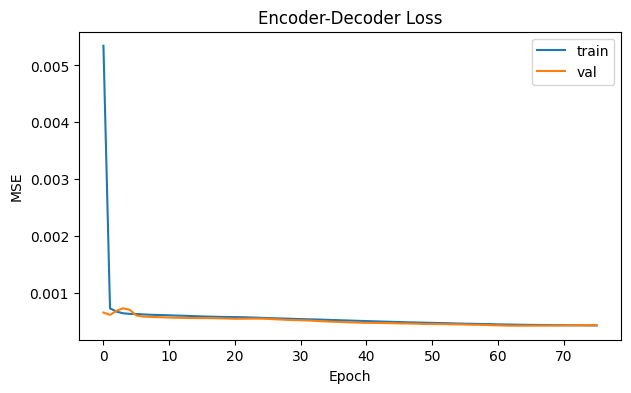

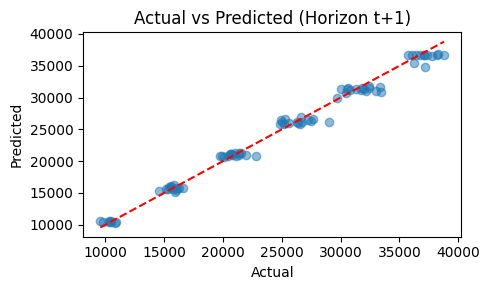

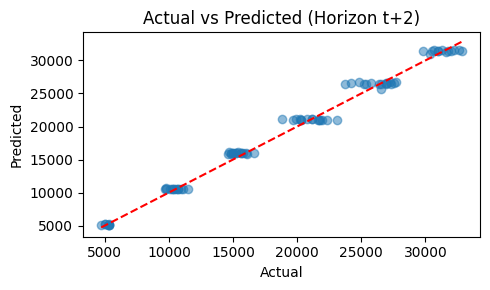

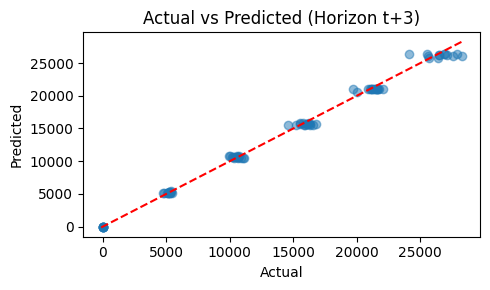


Saved model and csv outputs in ./models and current directory.


In [2]:
# === Combined: synthesize timeseries + encoder-decoder LSTM (one-shot) ===
import os, sys, numpy as np, pandas as pd, matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import LSTM, RepeatVector, TimeDistributed, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import joblib

# reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# PARAMETERS (tune these if needed)
SEQ_LEN = 12         # input window length
OUT_STEPS = 3        # forecast horizon
SYNTH_STEPS = SEQ_LEN + OUT_STEPS + 5   # length of synthetic series per player
BATCH_SIZE = 128
EPOCHS = 120
LATENT_DIM = 128

# 1) Load a player features file (try a few likely names)
candidates = ["player_features_final.csv", "transfermarkt_preprocessed.csv", "player_synth_timeseries.csv", "final_cleaned_fifa.csv"]
loaded = False
for fname in candidates:
    if os.path.exists(fname):
        try:
            df0 = pd.read_csv(fname)
            print(f"Loaded {fname} ({len(df0)} rows)")
            loaded = True
            break
        except Exception as e:
            print(f"Found {fname} but failed to read: {e}")
if not loaded:
    raise SystemExit("No player_features_final.csv or alternative found in working directory. Please upload it or place it here.")

# 2) Ensure required columns exist, create defaults if missing
if 'player_id' not in df0.columns:
    # try to create player_id from index
    df0 = df0.reset_index().rename(columns={'index':'player_id'})
    print("Created 'player_id' from dataframe index.")

if 'market_value_in_eur' not in df0.columns:
    # try common alternate names
    alt = [c for c in ['market_value','market_value_eur','value','value_eur'] if c in df0.columns]
    if alt:
        df0['market_value_in_eur'] = pd.to_numeric(df0[alt[0]], errors='coerce')
        print(f"Mapped alternate column '{alt[0]}' -> market_value_in_eur")
    else:
        raise SystemExit("No market value column found (need 'market_value_in_eur').")

# optional features: sentiment_score, injury_flag
if 'sentiment_score' not in df0.columns:
    print("No 'sentiment_score' found → creating neutral sentiment (0.0) per player.")
    df0['sentiment_score'] = 0.0
if 'injury_flag' not in df0.columns:
    print("No 'injury_flag' found → creating synthetic low-probability injury flags (0/1).")
    df0['injury_flag'] = 0

# keep only necessary columns and drop NaNs in market value
df0 = df0[['player_id','market_value_in_eur','sentiment_score','injury_flag']].dropna(subset=['market_value_in_eur'])
df0['market_value_in_eur'] = pd.to_numeric(df0['market_value_in_eur'], errors='coerce').fillna(0.0)

# 3) Synthesize per-player timeseries if there is only one row per player
counts = df0['player_id'].value_counts()
if counts.max() > 1:
    print("Dataset already contains >1 row per some players. Building sequences from existing rows where possible.")
    # convert existing into synth_df style by adding timestep if not present
    # create df grouped by player with artificial timestep ordering if no 'timestep' exists
    if 'timestep' not in df0.columns:
        df0 = df0.reset_index(drop=True)
        df0['timestep'] = 0
    synth_df = df0.copy()
else:
    print("Single snapshot per player detected — synthesizing short historical series (for demo).")
    rows = []
    for _, r in df0.iterrows():
        pid = r['player_id']
        cur = float(r['market_value_in_eur'])
        # use synthetic 'peak' as slightly higher than current or existing small base
        peak = max(cur * 1.3, cur + 1e5)
        # linear fade from peak -> current
        vals = np.linspace(peak, cur, SYNTH_STEPS)
        # add multiplicative noise
        noise = 1 + np.random.normal(0, 0.04, size=SYNTH_STEPS)
        vals_noisy = vals * noise
        # sentiment variation
        base_sent = float(r.get('sentiment_score', 0.0) or 0.0)
        sent = base_sent + np.random.normal(0, 0.02, size=SYNTH_STEPS)
        # injury flag synthetic (rare)
        inj = np.random.binomial(1, 0.03, size=SYNTH_STEPS)
        for t in range(SYNTH_STEPS):
            rows.append({
                'player_id': pid,
                'timestep': t,
                'market_value_in_eur': float(vals_noisy[t]),
                'sentiment_score': float(sent[t]),
                'injury_flag': int(inj[t])
            })
    synth_df = pd.DataFrame(rows)
    print("Synthetic time-series created with rows:", len(synth_df))

# quick sanity
print("synth_df sample:")
print(synth_df.head())

# 4) Build sequences for encoder-decoder
def build_sequences_local(df_ts, feature_cols, value_col='market_value_in_eur', seq_len=SEQ_LEN, pred_steps=OUT_STEPS, player_col='player_id', time_col='timestep'):
    X_list, y_list = [], []
    grouped = df_ts.groupby(player_col)
    for pid, g in grouped:
        if time_col in g.columns:
            g = g.sort_values(time_col)
        else:
            g = g.reset_index(drop=True)
        if len(g) < seq_len + pred_steps:
            continue
        arr = g[feature_cols].values
        vals = g[value_col].values
        for i in range(len(g) - seq_len - pred_steps + 1):
            X_list.append(arr[i:i+seq_len])
            y_list.append(vals[i+seq_len:i+seq_len+pred_steps])
    if not X_list:
        return None, None
    X = np.array(X_list)
    y = np.array(y_list)
    return X, y

# choose features (market_value + sentiment + injury if present)
feat_cands = ['market_value_in_eur','sentiment_score','injury_flag']
feature_cols = [c for c in feat_cands if c in synth_df.columns]
print("Features used:", feature_cols)

X_ed, y_ed = build_sequences_local(synth_df, feature_cols, seq_len=SEQ_LEN, pred_steps=OUT_STEPS)
if X_ed is None:
    raise SystemExit("Not enough sequences for chosen SEQ_LEN/OUT_STEPS. Try lowering SEQ_LEN or OUT_STEPS or create longer synthetic series.")

print("Built sequences. X shape:", X_ed.shape, "y shape:", y_ed.shape)

# reshape y to (samples, out_steps, 1)
y_ed_3d = y_ed.reshape(y_ed.shape[0], y_ed.shape[1], 1)

# train-test split
Xtr, Xte, ytr, yte = train_test_split(X_ed, y_ed_3d, test_size=0.2, random_state=42, shuffle=True)
print("Train samples:", Xtr.shape[0], "Test samples:", Xte.shape[0])

# 5) Scale X and y (fit on train only)
ns, sl, nf = Xtr.shape
X_scaler = MinMaxScaler().fit(Xtr.reshape(-1, nf))
Xtr_s = X_scaler.transform(Xtr.reshape(-1, nf)).reshape(ns, sl, nf)
Xte_s = X_scaler.transform(Xte.reshape(-1, nf)).reshape(Xte.shape[0], sl, nf)

y_scaler = MinMaxScaler().fit(ytr.reshape(-1,1))
ytr_s = y_scaler.transform(ytr.reshape(-1,1)).reshape(ytr.shape)
yte_s = y_scaler.transform(yte.reshape(-1,1)).reshape(yte.shape)

print("Scaling done. Xtr_s:", Xtr_s.shape, "ytr_s:", ytr_s.shape)

# 6) Build encoder-decoder model
from tensorflow.keras import Input
input_layer = Input(shape=(SEQ_LEN, nf))
enc = LSTM(LATENT_DIM, return_sequences=False)(input_layer)
rep = RepeatVector(OUT_STEPS)(enc)
dec = LSTM(LATENT_DIM, return_sequences=True)(rep)
dec = TimeDistributed(Dense(64, activation='relu'))(dec)
out = TimeDistributed(Dense(1))(dec)
model_ed = Model(inputs=input_layer, outputs=out)
model_ed.compile(optimizer='adam', loss='mse')
print(model_ed.summary())

# 7) Train
es = EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True)
history_ed = model_ed.fit(Xtr_s, ytr_s, validation_split=0.1, epochs=EPOCHS, batch_size=BATCH_SIZE, callbacks=[es], verbose=1)

# 8) Predict & invert scales
y_pred_s = model_ed.predict(Xte_s)   # (samples, out_steps, 1)
y_pred_flat = y_pred_s.reshape(-1,1)
y_pred_inv = y_scaler.inverse_transform(y_pred_flat).reshape(y_pred_s.shape[0], OUT_STEPS)
y_true_inv = yte.reshape(yte.shape[0], OUT_STEPS)

# 9) Metrics per horizon & overall
mse_per_horizon = ((y_true_inv - y_pred_inv)**2).mean(axis=0)
rmse_per_horizon = np.sqrt(mse_per_horizon)
mae_per_horizon = np.mean(np.abs(y_true_inv - y_pred_inv), axis=0)

print("\nEncoder-Decoder Metrics per horizon:")
for i, (r, a) in enumerate(zip(rmse_per_horizon, mae_per_horizon), start=1):
    print(f"  Horizon t+{i}: RMSE = {r:.2f}, MAE = {a:.2f}")

mse_all = mean_squared_error(y_true_inv.flatten(), y_pred_inv.flatten())
rmse_all = np.sqrt(mse_all)
mae_all = mean_absolute_error(y_true_inv.flatten(), y_pred_inv.flatten())
print(f"\nOverall RMSE: {rmse_all:.2f}, Overall MAE: {mae_all:.2f}")

# 10) Plot loss and example actual vs predicted
plt.figure(figsize=(7,4))
plt.plot(history_ed.history.get('loss', []), label='train')
plt.plot(history_ed.history.get('val_loss', []), label='val')
plt.title('Encoder-Decoder Loss')
plt.xlabel('Epoch'); plt.ylabel('MSE'); plt.legend(); plt.show()

nplot = min(80, y_true_inv.shape[0])
for h in range(OUT_STEPS):
    plt.figure(figsize=(5,3))
    plt.scatter(y_true_inv[:nplot, h], y_pred_inv[:nplot, h], alpha=0.5)
    mn = min(y_true_inv[:nplot,h].min(), y_pred_inv[:nplot,h].min())
    mx = max(y_true_inv[:nplot,h].max(), y_pred_inv[:nplot,h].max())
    plt.plot([mn,mx],[mn,mx],'r--')
    plt.title(f'Actual vs Predicted (Horizon t+{h+1})')
    plt.xlabel('Actual'); plt.ylabel('Predicted'); plt.tight_layout(); plt.show()

# 11) Save model, scalers, and CSVs
os.makedirs('models', exist_ok=True)
model_ed.save("models/encoder_decoder_lstm.h5")
joblib.dump(X_scaler, "models/ed_X_scaler.save")
joblib.dump(y_scaler, "models/ed_y_scaler.save")
pd.DataFrame(y_pred_inv, columns=[f"pred_t+{i+1}" for i in range(OUT_STEPS)]).to_csv("encoder_decoder_predictions.csv", index=False)
pd.DataFrame(y_true_inv, columns=[f"true_t+{i+1}" for i in range(OUT_STEPS)]).to_csv("encoder_decoder_true.csv", index=False)

print("\nSaved model and csv outputs in ./models and current directory.")
